# Lectures 4–5: two ways to analyse the same experiment
**A guided demo · about 35–45 minutes**

We measure two quantities several times and want to estimate their average values.
First we use confidence intervals and regions; then we analyse the **same data** with a Bayesian prior.

All code is complete. Run the cells in order, look at the figures, and pause at the short questions.
The only suggested edits are changing a sample size or a random seed. The calculations use the
simple Gaussian model from the lectures, so we can obtain the posterior directly.

Short derivation sections explain the confidence interval and the confidence and credible
regions. The 35–45 minute guide is for the plots and discussion; allow extra time to
work through the derivations together.

An early [1D confidence-interval reference](#known-variance-mean-ci) gives the derivation
for a known measurement variance, before the setup and demo.

The route is: **data → confidence interval → repeated experiments → two-dimensional region →
posterior → posterior draws → effect of the prior**.

Keep [lectures_04_05_helpers.py](lectures_04_05_helpers.py) next to this notebook.
The [presenter notes](lectures_04_05_mean_analysis_solutions.ipynb) contain suggested answers.


<a id="known-variance-mean-ci"></a>

## Reference: a 1D confidence interval for the mean with known variance

This is the scalar version of the known-covariance experiment. For a single scalar observation,
its covariance is simply its variance, $\sigma^2$. Assume **independent Gaussian measurements**
with a common unknown mean and known variance $\sigma^2>0$:

$$X_i\overset{\mathrm{iid}}\sim\mathcal N(\mu,\sigma^2),\qquad i=1,\ldots,n.$$

### 1. Find the sampling distribution of the mean

Estimate $\mu$ using the sample mean $\bar X=n^{-1}\sum_i X_i$.
Linearity of expectation and independence give

$$
\mathbb E[\bar X]=\frac1n\sum_i\mathbb E[X_i]=\mu,\qquad
\operatorname{Var}(\bar X)
=\frac1{n^2}\sum_i\operatorname{Var}(X_i)=\frac{\sigma^2}{n}.
$$

An average of independent Gaussian variables is Gaussian. Therefore

$$\bar X\sim\mathcal N\!\left(\mu,\frac{\sigma^2}{n}\right),\qquad
\mathrm{SE}=\frac{\sigma}{\sqrt n}.$$

Here $\sigma$ describes the spread of **individual observations**, while the standard error
$\mathrm{SE}$ describes the spread of their **sample mean across repeated experiments**.

### 2. Standardise and choose the desired probability

Because $\sigma$ is known,

$$T=\frac{\bar X-\mu}{\sigma/\sqrt n}\sim\mathcal N(0,1).$$

For a confidence level $0<q<1$, choose
$z_q=\Phi^{-1}((1+q)/2)$, where $\Phi$ is the standard normal cumulative distribution function.
This leaves probability $(1-q)/2$ in each tail, so

$$\Pr_\mu\!\left(-z_q\leq\frac{\bar X-\mu}{\mathrm{SE}}\leq z_q\right)=q.$$

The subscript $\mu$ means that the probability is over new datasets while the true mean is held fixed.

### 3. Rearrange the inequalities to obtain the interval

The event in this probability can be written as

$$
-z_q\,\mathrm{SE}\leq\bar X-\mu\leq z_q\,\mathrm{SE}
\quad\Longleftrightarrow\quad
\bar X-z_q\,\mathrm{SE}\leq\mu\leq\bar X+z_q\,\mathrm{SE}.
$$

Consequently,

$$\Pr_\mu\!\left(
\bar X-z_q\frac{\sigma}{\sqrt n}\leq\mu\leq
\bar X+z_q\frac{\sigma}{\sqrt n}\right)=q.$$

After observing the data, replace $\bar X$ by the observed sample mean $\bar x$:

$$\boxed{
C_q(D)=\left[\bar x-z_q\frac{\sigma}{\sqrt n},\;
             \bar x+z_q\frac{\sigma}{\sqrt n}\right].
}$$

For $q=0.95$, $z_q=\Phi^{-1}(0.975)\approx1.96$, giving the familiar result

$$\boxed{\text{95\% confidence interval:}\qquad
\bar x\pm1.96\,\frac{\sigma}{\sqrt n}.}$$

For example, with $n=12$ and $\sigma=1$, the standard error is approximately $0.289$ and the
interval is $\bar x\pm0.566$.

The exact normal cutoff gives **95% coverage over repeated experiments** under these assumptions;
1.96 is its rounded display value. After observing one interval, this frequentist calculation
does not assign a posterior probability to the fixed mean. Gaussianity and the known variance
make the result exact for every $n$; a known covariance alone would not justify an exact normal
interval for arbitrary non-Gaussian measurements.

**Connection to the demo:** for the first component of the two-dimensional measurements below,
set $\mu=\mu_1$ and $\sigma^2=\Sigma_{11}$. The standard error is then
$\sqrt{\Sigma_{11}/n}$, exactly as used in the code.


## Setup

Use the same `tutorials/.venv` environment as the earlier tutorials and select it as the notebook kernel.
There are no new packages to install for this demo. If you need to start Jupyter, run this in a terminal
at the repository root:

```bash
cd tutorials
source .venv/bin/activate
python -m jupyterlab
```

For a first installation, run `uv venv --python 3.12` inside `tutorials`, then
`uv pip install --python .venv -r requirements.txt` before activating the environment.
On Windows PowerShell, use `.venv\Scripts\Activate.ps1` to activate it.

Run all cells once. After changing the sample size or data seed below, rerun the notebook from that cell.


In [1]:
import jax
import jax.numpy as jnp
from jax import random
from jax.scipy.special import ndtri
import matplotlib.pyplot as plt

from lectures_04_05_helpers import (
    gaussian_posterior, plot_scalar_observations,
    plot_confidence_intervals, plot_regions,
)

jax.config.update("jax_enable_x64", True)
plt.style.use("default")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
level = 0.95
z = ndtri((1 + level) / 2)  # Supplied normal cutoff: approximately 1.96.


## 1. Look at the measurements

Each observation has two components, $(x_1,x_2)$. We use the familiar experiment

$$\mathbf X_i\sim\mathcal N_2(\boldsymbol\mu,\Sigma),\qquad
\Sigma=\begin{pmatrix}1&0.6\\0.6&1.5\end{pmatrix}.$$

The observations are independent of each other. The two components of an observation are correlated.
The mean $\boldsymbol\mu$ is unknown and the covariance $\Sigma$ is **known**.

For this simulation we set the true mean to $(1,-0.5)$. We use the truth to generate the data and
check our results; the inference calculations only use the measurements and the assumed model.
Each dot below is one observation. The cross is their sample mean.


Number of observations: 12
Sample mean: [ 0.779 -0.457]


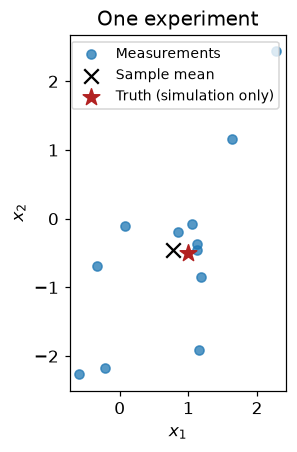

In [2]:
# The two easy settings to try changing later.
n = 12
data_seed = 405

mu_true = jnp.array([1.0, -0.5])
Sigma = jnp.array([[1.0, 0.6], [0.6, 1.5]])
data = random.multivariate_normal(random.key(data_seed), mu_true, Sigma, shape=(n,))
mu_hat = data.mean(axis=0)
V = Sigma / n  # Covariance of the sample mean.

print(f"Number of observations: {n}")
print("Sample mean:", jnp.round(mu_hat, 3))
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.scatter(data[:, 0], data[:, 1], alpha=0.75, label="Measurements")
ax.scatter(*mu_hat, marker="x", color="black", s=90, label="Sample mean")
ax.scatter(*mu_true, marker="*", color="firebrick", s=130, label="Truth (simulation only)")
ax.set(xlabel=r"$x_1$", ylabel=r"$x_2$", title="One experiment", aspect="equal")
ax.legend(fontsize=9)
plt.show()


**Pause and predict.** Would another experiment give exactly the same sample mean?


## 2. Lecture 4: a confidence interval for the first mean

See the [earlier 1D derivation](#known-variance-mean-ci) for the full argument.

Start with just the first component. Its sample mean estimates $\mu_1$.
Because the measurement variance is known, the standard error of that estimate is

$$\mathrm{SE}=\frac{\sigma_1}{\sqrt n},\qquad \sigma_1=\sqrt{\Sigma_{11}}=1.$$

Under this Gaussian model, the 95% confidence interval is

$$\text{sample mean}\;\pm\;1.96\times\mathrm{SE}.$$

Here 1.96 is the rounded normal cutoff; the code uses its full numerical value.

The first row of the plot shows individual observations. The second shows the estimate and its interval.


Estimated first mean: 0.779
Standard error: 0.289
95% confidence interval: [0.213 1.344]


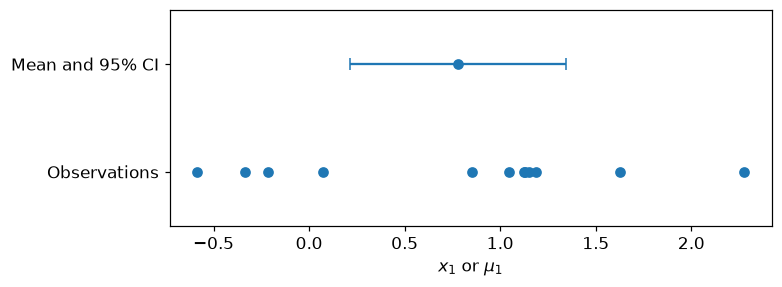

In [3]:
scalar_estimate = mu_hat[0]
scalar_se = jnp.sqrt(Sigma[0, 0] / n)
scalar_ci = scalar_estimate + jnp.array([-1.0, 1.0]) * z * scalar_se

print(f"Estimated first mean: {float(scalar_estimate):.3f}")
print(f"Standard error: {float(scalar_se):.3f}")
print("95% confidence interval:", jnp.round(scalar_ci, 3))
plot_scalar_observations(data[:, 0], scalar_estimate, scalar_ci)


**Pause and predict.** If we collect four times as many observations, should this interval
be wider or narrower?


## 3. What does 95% confidence mean?

Repeat the **whole experiment**, keeping the true mean, sample size, and covariance fixed.
Make one interval from each new dataset.

The figure shows the first 40 intervals. The printed fraction uses 2,000 experiments.
Intervals move because the data change; the vertical line marking the true mean stays fixed.
These simulated repetitions help us understand the procedure. They are separate from our original dataset.


Intervals containing the fixed true mean: 94.6%


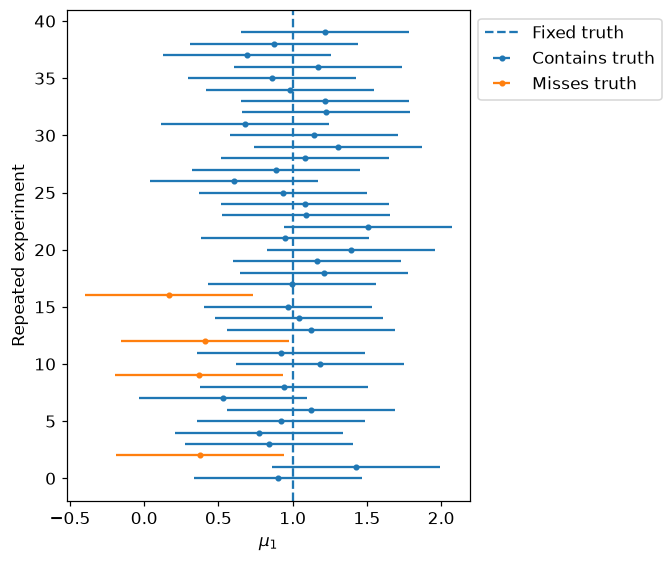

In [4]:
number_of_experiments = 2000
repeated_data = random.multivariate_normal(
    random.key(406), mu_true, Sigma, shape=(number_of_experiments, n),
)
repeated_means = repeated_data.mean(axis=1)  # One mean per experiment.
lower = repeated_means[:, 0] - z * scalar_se
upper = repeated_means[:, 0] + z * scalar_se
contains_truth = (lower <= mu_true[0]) & (mu_true[0] <= upper)
coverage = jnp.mean(contains_truth)

print(f"Intervals containing the fixed true mean: {100 * float(coverage):.1f}%")
plot_confidence_intervals(repeated_means[:40, 0], lower[:40], upper[:40], mu_true[0])


**Look and discuss.** Do all intervals contain the truth? What does the 95% refer to?


## 4. Use both components: a confidence region

Our estimate is now a point, $\widehat{\boldsymbol\mu}=\bar{\mathbf x}$, and its uncertainty is a region.
The covariance of the sample mean is $V=\Sigma/n$.

The boundary below is a **joint 95% confidence ellipse** for the two mean components.
Its tilt reflects the correlation between them. It concerns the location of the mean;
it does not describe the spread of individual observations.

We return to the original dataset for this plot and for the Bayesian analysis that follows.


### Derivation: why the joint confidence region is an ellipse

The vector sample mean has sampling distribution

$$\bar{\mathbf X}\sim\mathcal N_2(\boldsymbol\mu,V),\qquad V=\Sigma/n.$$

Write $V=LL^{\mathsf T}$ using a Cholesky factor. Subtracting the true mean and multiplying by
$L^{-1}$ removes the correlation and rescales the errors to unit variance:

$$\mathbf Z=L^{-1}(\bar{\mathbf X}-\boldsymbol\mu)\sim\mathcal N_2(\mathbf0,I_2).$$

Thus $Z_1$ and $Z_2$ are independent standard normals. Their squared sum has a chi-squared
distribution with two degrees of freedom:

$$
Q=Z_1^2+Z_2^2
=(\bar{\mathbf X}-\boldsymbol\mu)^{\mathsf T}V^{-1}
 (\bar{\mathbf X}-\boldsymbol\mu)\sim\chi^2_2.
$$

Choose $c_q$ so that $\Pr(Q\leq c_q)=q$. In two dimensions,
$\Pr(Q\leq c)=1-e^{-c/2}$, so $c_q=-2\log(1-q)$ and $c_{0.95}\approx5.991$.
Replacing the random sample mean by its observed value gives

$$\boxed{
C_q(D)=\left\{\boldsymbol\mu:
(\bar{\mathbf x}-\boldsymbol\mu)^{\mathsf T}V^{-1}
(\bar{\mathbf x}-\boldsymbol\mu)\leq c_q\right\}.
}$$

A quadratic-distance boundary is an ellipse. For every fixed true mean, the probability
that this procedure's ellipse contains it is $q$. The joint 95% cutoff is **5.991**;
using $1.96^2$ would not give 95% coverage for a two-dimensional region.


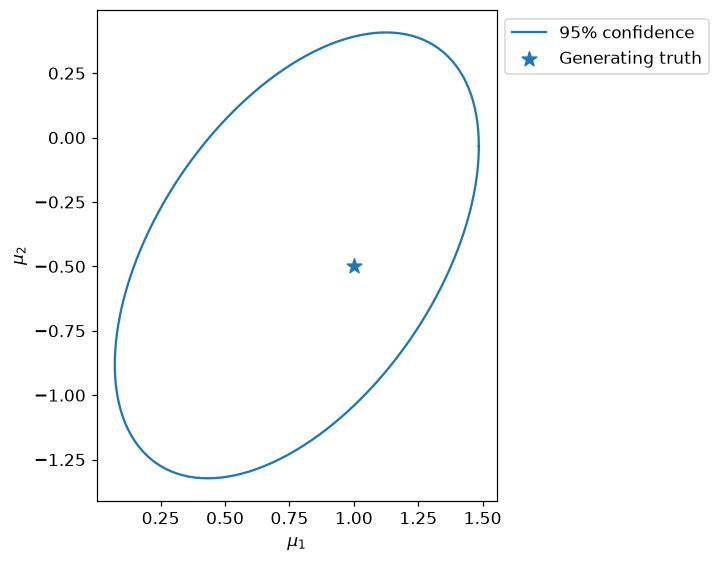

In [5]:
plot_regions({"95% confidence": (mu_hat, V)}, truth=mu_true, level=level)


**Look and discuss.** What are the axes in this plot: individual measurements or possible mean values?


## 5. Lecture 5: add a prior and calculate the posterior

Keep the **same observations and covariance**. Bayesian inference combines a prior with the likelihood:

$$p(\boldsymbol\mu\mid D)\propto p(D\mid\boldsymbol\mu)\,p(\boldsymbol\mu).$$

Begin with a broad Gaussian prior centred at zero, with covariance $2I_2$.
Its standard deviation is $\sqrt2\approx1.41$ for each mean component.
For this simple experiment the posterior is also Gaussian, and a supplied function calculates it exactly.

Compare the confidence ellipse with the **95% highest posterior density credible ellipse**. Given the observed data,
prior, and sampling model, the credible ellipse contains 95% of the posterior probability for the mean.


### Derivation: the Gaussian posterior

Let the prior be $\boldsymbol\mu\sim\mathcal N_2(\mathbf m_0,C_0)$.
Here $\mathbf m_0=\mathbf0$ and $C_0=2I_2$. Continue to write $V=\Sigma/n$.

The sum of the observation quadratics can be split into scatter around the sample mean
and displacement of a proposed mean:

$$
\sum_i(\mathbf x_i-\boldsymbol\mu)^{\mathsf T}\Sigma^{-1}
(\mathbf x_i-\boldsymbol\mu)
=\sum_i(\mathbf x_i-\bar{\mathbf x})^{\mathsf T}\Sigma^{-1}
(\mathbf x_i-\bar{\mathbf x})
+(\boldsymbol\mu-\bar{\mathbf x})^{\mathsf T}V^{-1}
(\boldsymbol\mu-\bar{\mathbf x}).
$$

The cross terms vanish because $\sum_i(\mathbf x_i-\bar{\mathbf x})=\mathbf0$.
The scatter term does not depend on $\boldsymbol\mu$, so Bayes' rule gives

$$
p(\boldsymbol\mu\mid D)\propto
\exp\!\left[-\frac12\left\{
(\boldsymbol\mu-\bar{\mathbf x})^{\mathsf T}V^{-1}(\boldsymbol\mu-\bar{\mathbf x})
+(\boldsymbol\mu-\mathbf m_0)^{\mathsf T}C_0^{-1}(\boldsymbol\mu-\mathbf m_0)
\right\}\right].
$$

Expand the two quadratics and collect terms involving $\boldsymbol\mu$:

$$
\boldsymbol\mu^{\mathsf T}(V^{-1}+C_0^{-1})\boldsymbol\mu
-2\boldsymbol\mu^{\mathsf T}(V^{-1}\bar{\mathbf x}+C_0^{-1}\mathbf m_0)
+\text{constant}.
$$

Define

$$\boxed{
C=(V^{-1}+C_0^{-1})^{-1},\qquad
\mathbf m=C(V^{-1}\bar{\mathbf x}+C_0^{-1}\mathbf m_0).
}$$

Completing the square turns the expression into
$(\boldsymbol\mu-\mathbf m)^{\mathsf T}C^{-1}(\boldsymbol\mu-\mathbf m)+\text{constant}$.
After normalisation,

$$\boxed{\boldsymbol\mu\mid D\sim\mathcal N_2(\mathbf m,C).}$$

These are `posterior_mean` and `posterior_cov` in the code. This derivation uses the observed
sample mean and the prior; it does not use the generating truth.


### Which credible region? Choose the highest posterior density

A $q$ credible region $R_q(D)$ must satisfy

$$\int_{R_q(D)}p(\boldsymbol\mu\mid D)\,d\boldsymbol\mu=q.$$

Many different regions can contain this probability. **We choose the highest posterior density
(HPD) region:** include the highest-density parameter values first, until we have enclosed $q$.
Write $f(\boldsymbol\mu)=p(\boldsymbol\mu\mid D)$ and choose the density threshold $t_q$ so that

$$\boxed{
R_q(D)=\{\boldsymbol\mu:f(\boldsymbol\mu)\geq t_q\},\qquad
\int_{R_q(D)}f(\boldsymbol\mu)\,d\boldsymbol\mu=q.
}$$

For the Gaussian posterior here, every point inside the chosen region has higher posterior
density than every point outside:

$$
\boldsymbol\mu_{\rm in}\in R_q(D),\quad
\boldsymbol\mu_{\rm out}\notin R_q(D)
\quad\Longrightarrow\quad
f(\boldsymbol\mu_{\rm in})\geq t_q>f(\boldsymbol\mu_{\rm out}).
$$

This is a statement about **density**. For a continuous parameter, the probability of any
one exact point is zero; probabilities are obtained by integrating over regions.
The Gaussian contour itself has zero probability, so including its boundary does not change the mass.

This choice gives the **smallest area containing the required probability**, or equivalently
**the greatest probability for its area**, in the displayed mean coordinates. To see why, imagine
replacing a small low-density patch by an equally sized higher-density patch: the area stays the
same and the enclosed probability increases. An HPD region leaves no such improvement available.
Without an area constraint, the whole parameter space would enclose the maximum probability, one.


### Derivation: from posterior density to the credible ellipse

Our normalised two-dimensional posterior is

$$
f(\boldsymbol\mu)=\frac{1}{2\pi\sqrt{|C|}}
\exp\!\left[-\frac12 r^2(\boldsymbol\mu)\right],\qquad
r^2(\boldsymbol\mu)=(\boldsymbol\mu-\mathbf m)^{\mathsf T}
C^{-1}(\boldsymbol\mu-\mathbf m),
$$

where $|C|$ is the determinant of $C$. The prefactor is fixed for the observed data and prior.
The density decreases as $r^2$ increases, so keeping the highest-density points means keeping
the points with the **smallest quadratic distance from the posterior mean**:

$$f(\boldsymbol\mu)\geq t_q
\quad\Longleftrightarrow\quad
r^2(\boldsymbol\mu)\leq c_q,\qquad
c_q=-2\log\!\left(2\pi\sqrt{|C|}\,t_q\right).$$

To select $c_q$, write $C=LL^{\mathsf T}$. Under the posterior,

$$\mathbf Z=L^{-1}(\boldsymbol\mu-\mathbf m)\mid D\sim\mathcal N_2(\mathbf0,I_2),
\qquad r^2=Z_1^2+Z_2^2\mid D\sim\chi^2_2.$$

Therefore $c_q=-2\log(1-q)$ again. For $q=0.95$, we obtain

$$\boxed{
R_{0.95}(D)=\left\{\boldsymbol\mu:
(\boldsymbol\mu-\mathbf m)^{\mathsf T}C^{-1}
(\boldsymbol\mu-\mathbf m)\leq5.991\ldots\right\}.
}$$

This is the HPD credible ellipse plotted below. Its enclosed posterior probability is 95%.
The ellipse looks like the confidence region because both use a Gaussian quadratic, but the
probability is now **over the mean under the posterior, with the observed data held fixed**.

For just the first mean component, the marginal posterior is
$\mu_1\mid D\sim\mathcal N(m_1,C_{11})$. Its density decreases away from $m_1$, so the highest-density
interval is symmetric about $m_1$. Standardising gives
$(\mu_1-m_1)/\sqrt{C_{11}}\mid D\sim\mathcal N(0,1)$ and hence

$$\boxed{R_q^{(1)}(D)=[m_1-z_q\sqrt{C_{11}},\;m_1+z_q\sqrt{C_{11}}].}$$

At 95%, $z_q\approx1.96$. This is a **marginal** credible interval; it is not the projection of
the joint 95% ellipse onto the first axis.


Sample mean:    [ 0.779 -0.457]
Posterior mean: [ 0.758 -0.448]


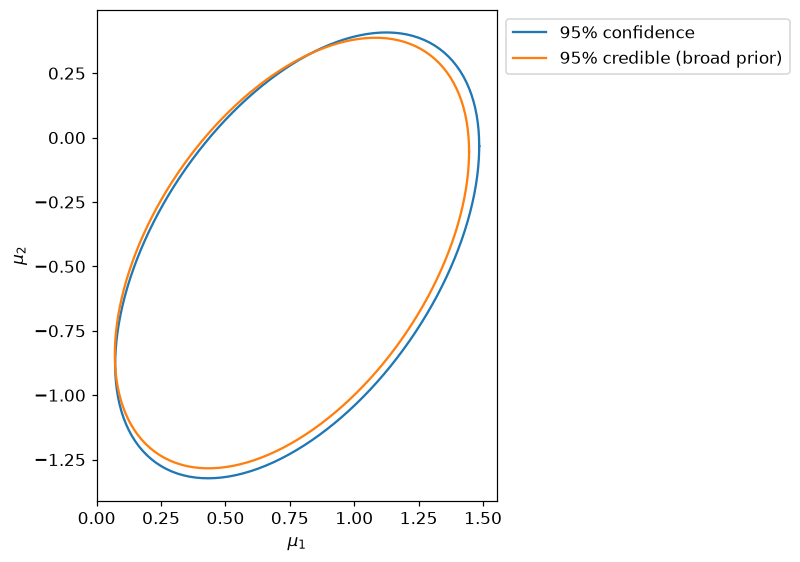

In [6]:
prior_mean = jnp.zeros(2)
prior_cov = 2.0 * jnp.eye(2)
posterior_mean, posterior_cov = gaussian_posterior(mu_hat, n, Sigma, prior_mean, prior_cov)

print("Sample mean:   ", jnp.round(mu_hat, 3))
print("Posterior mean:", jnp.round(posterior_mean, 3))
plot_regions({
    "95% confidence": (mu_hat, V),
    "95% credible (broad prior)": (posterior_mean, posterior_cov),
}, level=level)


**Look and discuss.** The two regions are close. Do they make the same probability statement?


## 6. Visualise the posterior with samples

We can draw possible mean values from the Gaussian posterior. These points are **parameter draws**,
not extra measurements and not new experiments. The data and posterior stay fixed.

Here we can draw independent samples directly. The cloud makes the posterior uncertainty visible.


Exact posterior mean:       [ 0.758 -0.448]


Average of posterior draws: [ 0.759 -0.45 ]


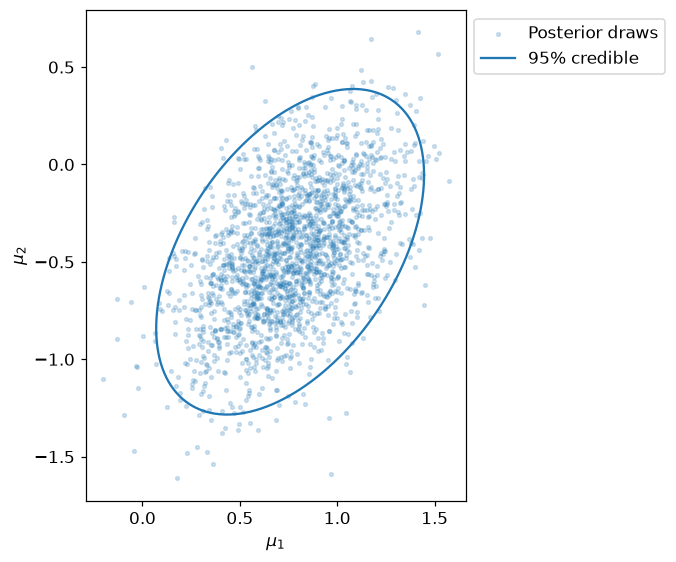

In [7]:
number_of_draws = 2000
posterior_draws = random.multivariate_normal(
    random.key(407), posterior_mean, posterior_cov, shape=(number_of_draws,),
)
print("Exact posterior mean:      ", jnp.round(posterior_mean, 3))
print("Average of posterior draws:", jnp.round(posterior_draws.mean(axis=0), 3))
plot_regions({"95% credible": (posterior_mean, posterior_cov)},
             samples=posterior_draws, level=level)


**Pause and predict.** Would drawing more posterior samples make the credible ellipse smaller?


## 7. Change the prior, keep the measurements

Compare three priors for the original dataset. The first is the broad prior above.
The other two place much stronger weight near their specified centres.

| Prior | Centre | Standard deviation in each component |
|---|---|---|
| Broad | $(0,0)$ | $\sqrt2\approx1.41$ |
| Narrow at zero | $(0,0)$ | $0.2$ |
| Narrow and shifted | $(0.8,-0.3)$ | $0.2$ |

**Predict before running:** how might a narrow prior change the centre and size of the posterior?
These are prescribed examples to demonstrate prior sensitivity; the plot is not a method for
choosing a prior after seeing the data.


Broad            posterior mean: [ 0.758 -0.448]
Narrow at zero   posterior mean: [ 0.339 -0.214]
Narrow shifted   posterior mean: [ 0.81  -0.341]


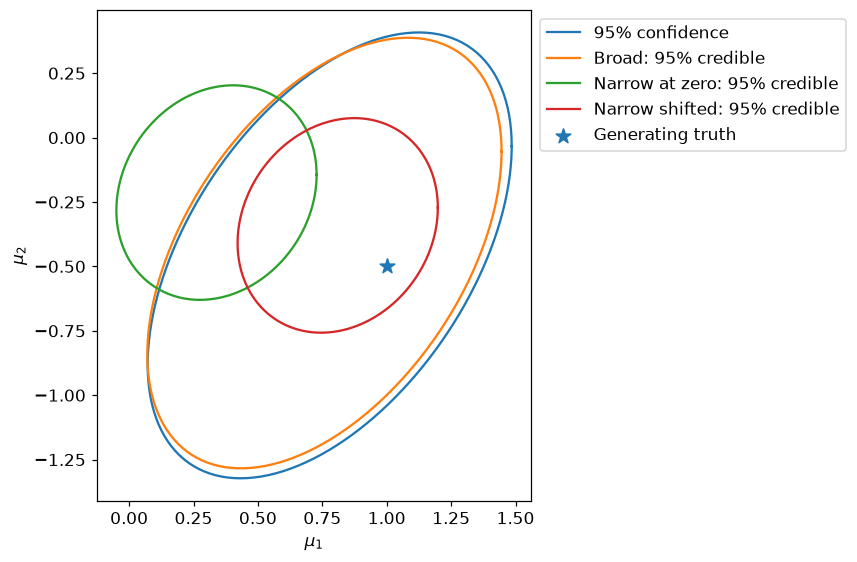

In [8]:
prior_settings = {
    "Broad": (prior_mean, prior_cov),
    "Narrow at zero": (jnp.zeros(2), 0.2**2 * jnp.eye(2)),
    "Narrow shifted": (jnp.array([0.8, -0.3]), 0.2**2 * jnp.eye(2)),
}
prior_results = {}
regions = {"95% confidence": (mu_hat, V)}
for label, (centre, covariance) in prior_settings.items():
    mean, covariance_after_data = gaussian_posterior(mu_hat, n, Sigma, centre, covariance)
    prior_results[label] = (mean, covariance_after_data)
    regions[label + ": 95% credible"] = (mean, covariance_after_data)
    print(f"{label:16s} posterior mean: {jnp.round(mean, 3)}")

plot_regions(regions, truth=mu_true, level=level)


**Look and discuss.** Does a smaller region necessarily put us closer to the truth?


## What to remember

| Calculation | Meaning |
|---|---|
| Sample mean | Our estimate from the observed measurements. |
| 95% confidence region | A procedure that covers the fixed true mean in 95% of repeated experiments under this model. |
| 95% credible region | A region containing 95% posterior probability for the mean, given these data, the model, and the prior. |
| Highest posterior density (HPD) choice | Include the highest-density values first: minimum area for the desired posterior probability. |
| Posterior samples | Numerical draws of possible parameter values from that posterior. |

**Two easy things to try:** change `n` from 12 to 48 and rerun from the data cell;
then change `data_seed` and rerun to see another experiment. Predict which features will change
before looking at the figures.

For further background, see the
[lecture 4 notebook](../04_frequentist/gaussian_mean_frequentist_inference.ipynb) and
[lecture 5 notebook](../05_bayesian/bayesian_gaussian_mean_inference.ipynb).
